In [1]:
from pathlib import Path
rootdir = Path("../../../..").resolve()
import sys
sys.path.insert(0, str(rootdir) )
from typing import Callable, Generator

import gemmi 
import parasail
import numpy as np
from rdkit import Chem

from xaidar.data.molecModels import get_pdb_stats, sele_pdb, sele_Lig, get_res_CoM
from xaidar.data.molecModels import flatten_pdb, sele_AA, createPDB, get_atom_coord

## Get Activity Data

In [2]:
import pandas as pd
import re

metadata_df = pd.read_csv( str(rootdir.joinpath( r"data/ev2a/fragalysis/01-concatDir/metadata.csv") ) )
cdd_df = pd.read_csv( rootdir.joinpath(r"data/ev2a/cdd/cdd_v3.csv"))


regex = re.compile( "weizmann")
new_columns_names = [ col if not regex.search(col) else "WEIZMAN" + col[regex.search(col).end():] for col in  cdd_df.columns.to_list() ]
regex = re.compile( "bienta")
new_columns_names = [ col if not regex.search(col) else "BIENTA" + col[regex.search(col).end():] for col in  new_columns_names]
regex = re.compile( "X-ray_Diamond")
new_columns_names = [ col if not regex.search(col) else "X-RAY"+ col[regex.search(col).end():] for col in  new_columns_names]
cdd_df.columns = new_columns_names


piperidine_df = metadata_df[ (metadata_df[ "[Series] Piperidine series"]==True ) ] # Select piperidine entries only
piperidine_singles_df = piperidine_df[ 
                        [ not (code [:-1] + "b" in piperidine_df["Code"].values) 
                        for code in piperidine_df["Code"].values ] 
                        ]  # Select datasets with single entries only (i.e., A1259a but not A1259b, ...c, etc)
piperidine_singles_df = piperidine_singles_df[ 
                        [ len( piperidine_singles_df[piperidine_singles_df["Experiment code"] == code ] ) == 1 
                        for code in piperidine_singles_df["Experiment code"] ] ] # Double check single entry datasets only (i.e., A71EV2A-x1292 with only one entry)

pip_exp_codes = piperidine_singles_df[ [ "Experiment code"]].values.flatten()
pip_exp_codes.sort()

pip_cdd_df =  cdd_df[ cdd_df["X-RAY: Dataset"].isin( pip_exp_codes ) ]

cdd_molecname_for_frag= [ list(pip_cdd_df[ pip_cdd_df["X-RAY: Dataset"] == expcode ]["Molecule Name"].unique())[0]
        if len( pip_cdd_df[ pip_cdd_df["X-RAY: Dataset"] == expcode ]["Molecule Name"].unique() ) != 0
        else None
        for expcode in piperidine_singles_df["Experiment code"]   ]

piperidine_singles_df.insert(0, "CDD Molecule Name",cdd_molecname_for_frag)

def is_convertible_to_float( obj) -> bool:
    """
    Checks if a string 's' can be safely converted to a float.
    Returns True if convertible, False otherwise.
    """
    try:
        float(obj)
        return True
    except ValueError:
        return False

cdd_ic50_for_frag= [ 
        pip_cdd_df[ pip_cdd_df["Molecule Name"] == molecName ]["WEIZMAN: IC50_GMean (µM)"].unique()[0]
          if ( len( pip_cdd_df[ pip_cdd_df["Molecule Name"] == molecName ]["WEIZMAN: IC50_GMean (µM)"].unique() ) != 0
              and is_convertible_to_float( pip_cdd_df[ pip_cdd_df["Molecule Name"] == molecName ]["WEIZMAN: IC50_GMean (µM)"].unique()[0] ))
    else pip_cdd_df[ pip_cdd_df["Molecule Name"] == molecName ]["BIENTA: IC50_GMean (µM)"].unique()[0]
          if ( len( pip_cdd_df[ pip_cdd_df["Molecule Name"] == molecName ]["BIENTA: IC50_GMean (µM)"].unique() ) != 0
              and is_convertible_to_float( pip_cdd_df[ pip_cdd_df["Molecule Name"] == molecName ]["BIENTA: IC50_GMean (µM)"].unique()[0] ))
        else None
        for _, molecName in piperidine_singles_df[["Experiment code","CDD Molecule Name"]].values   ]

piperidine_singles_df.insert(1, "CDD Mean IC 50",cdd_ic50_for_frag)
display( piperidine_singles_df[piperidine_singles_df["CDD Mean IC 50"].notna()].head(5) )
# display( piperidine_singles_df.sort_values("CDD Mean IC 50").iloc[ :, :65].head(5) )


,CDD Molecule Name,CDD Mean IC 50,Code,Long code,Experiment code,Compound code,Smiles,Centroid res,Downloaded,ConformerSites upload name,...,[Other] upload_5 2025-04-10,[Other] upload_1 2024-12-06,[Other] upload_1 2025-02-12,[Other] upload_2 2025-02-28,[Other] upload_6 2025-09-15,Main status,GOOD count,MEDIOCRE count,BAD count,RefinementResolution
141,ASAP-0031746,19.8,A3186a,A71EV2A-x3186_D_245_v1,A71EV2A-x3186,ASAP-0031746-001,COc1ccccc1CC(=O)N1CCC[C@H](C(N)=O)C1,A71EV2A-x0911/A/133/A_v1,True,1b - A71EV2A-x0911/A/147,...,False,True,False,False,False,NaN,NaN,NaN,NaN,2.060
148,ASAP-0031919,46.8,A3207a,A71EV2A-x3207_A_201_v1,A71EV2A-x3207,ASAP-0031919-001,NC(=O)[C@H]1CCCN(C(=O)Cc2ccnc(N)c2)C1,A71EV2A-x0911/A/133/A_v1,True,1b - A71EV2A-x0911/A/147,...,False,True,False,False,False,NaN,NaN,NaN,NaN,1.687
149,ASAP-0031936,60.1,A3208a,A71EV2A-x3208_A_201_v1,A71EV2A-x3208,ASAP-0031936-001,NC(=O)[C@H]1CCCN(C(=O)Cc2cc(C(F)(F)F)ccc2Cl)C1,A71EV2A-x0911/A/133/A_v1,True,1b - A71EV2A-x0911/A/147,...,False,False,False,False,False,NaN,NaN,NaN,NaN,1.470
155,ASAP-0031970,46.9,A3225a,A71EV2A-x3225_A_201_v1,A71EV2A-x3225,ASAP-0031970-001,Cc1nc2ccccc2n1CC(=O)N1CCC[C@H](C(N)=O)C1,A71EV2A-x0911/A/133/A_v1,True,1b - A71EV2A-x0911/A/147,...,False,False,False,False,False,NaN,NaN,NaN,NaN,1.891
156,ASAP-0031947,12.2,A3229a,A71EV2A-x3229_A_201_v1,A71EV2A-x3229,ASAP-0031947-001,COc1ccncc1CC(=O)N1CCC[C@H](C(N)=O)C1,A71EV2A-x0911/A/133/A_v1,True,1b - A71EV2A-x0911/A/147,...,False,False,False,False,False,NaN,NaN,NaN,NaN,1.790


In [3]:
piperidine_dataset_codes = piperidine_singles_df[piperidine_singles_df["CDD Mean IC 50"].notna()]["Code"].tolist()
piperidine_ic50_values = piperidine_singles_df[piperidine_singles_df["CDD Mean IC 50"].notna()]["CDD Mean IC 50"].tolist()
piperidine_ic50_values = np.array( [ float( ic50 ) for ic50 in piperidine_ic50_values ] )
print( "Number of Piperidine Datasets with IC 50 values: ", len(piperidine_dataset_codes) )

Number of Piperidine Datasets with IC 50 values:  65


# Get Structural Data

- ## Load Proteins and Fragments of Interest

In [4]:
from xaidar.data.protocols import load_and_filter_Proteins, extract_lig_from_prot
from xaidar.data.molecModels import get_res_CoM, sele_pdb, sele_Lig, flatten_pdb, sele_closest_Chain, get_pdb_stats
# 1. Loading Fragalyis data Root Directory
rootProjDir = rootdir / "data/ev2a/fragalysis"
fragalysisDir =  rootdir / "data/ev2a/fragalysis"

# 2. Load Fragalysis Protein Directories
nonactivepdbs_dir = fragalysisDir / "02-chemofint/nonactivesite"
fragscreen_dir = fragalysisDir / "02-chemofint/fragscreen"
piperid_dir = fragalysisDir / "02-chemofint/piperid"
ref_dir = fragalysisDir / "02-chemofint/reference"

ref_obj = gemmi.read_pdb( str( next(ref_dir.glob( "??????.pdb" )) ) )
ref_lig = sele_pdb( ref_obj, sele_Lig )
lig_CoM = gemmi.Position( *get_res_CoM( flatten_pdb( ref_lig, "residue" ) )[0])
ref_prot = sele_pdb( sele_pdb( ref_obj, sele_AA ), sele_closest_Chain, lig_CoM)


def process_lig_prot(pdb_dir: Path, ) -> dict:
    num_chains = None
    num_lig_chains = None # Number of chains with ligands
    if num_chains > 1 and num_lig_chains > 1:
        pass
    elif num_chains >1 and num_lig_chains == 1:
        pass
    elif num_chains == 1 and num_lig_chains ==1:
        pass

- ### Filter Proteins that do not have the same molecule

- ## Get Reference Protein Active Site Amino Acids

In [5]:
# Load Ligands from Piperid Datasets that are in the active site
ligs, ligs_datasets,  logs = extract_lig_from_prot( piperid_dir, coord = get_res_CoM( flatten_pdb( ref_lig, "residue" ) )[0] )

ligs_CoM = np.array([ np.array(get_res_CoM( flatten_pdb( lig, "residue") )[0]) if lig is not None else None for lig in ligs ])
mean_CoM = np.mean( ligs_CoM, axis = 0)

ligs_dist = [ np.linalg.norm( mean_CoM - lig_CoM ) for lig_CoM in ligs_CoM ]
standard_dataset_indexs = [ idx for idx, value in enumerate(ligs_dist) if value <= 5]
updated_mean_CoM = np.mean( [ ligs_CoM[idx] for idx in standard_dataset_indexs] , axis = 0)
# Update Ligands based on new CoM
ligs, ligs_datasets,  logs = extract_lig_from_prot( piperid_dir, coord = updated_mean_CoM )

ligs_res_lst = [ flatten_pdb( lig, "residue")[0] for lig in ligs ]



In [6]:
from xaidar.data.molecModels import get_pairwise_dist
from collections import defaultdict
activesite_aa_set = set()
activesite_aa_set_idx = set()
activesite_aa_per_dataset = defaultdict( list)

# Get active site aas for reference protein pdb
for chain in ref_prot[0]:                                                       # Protein Chains
    res_CoMs = get_res_CoM( chain.whole() )
    res_lst  = [ (idx, res) for idx, res in enumerate(chain.whole()) if np.linalg.norm( res_CoMs[idx] - updated_mean_CoM) < 15.0 ]
    for res_idx, prot_res in res_lst:                                                    # 
        res_atom_pos = np.array( [  np.array( [atom.pos.x,atom.pos.y, atom.pos.z] ) for atom in  prot_res] )
        for lig_res, lig_dataset_name in zip(ligs_res_lst,ligs_datasets ):          # Ligands
          lig_atom_pos = np.array( [  np.array( [atom.pos.x,atom.pos.y, atom.pos.z] ) for atom in  lig_res] )
          if np.min( get_pairwise_dist(res_atom_pos, lig_atom_pos) ) < 5.0:     # Amino acids within 5A of ligand
              activesite_aa_set.add( prot_res )
              activesite_aa_set_idx.add(res_idx)
              activesite_aa_per_dataset[lig_dataset_name].append( prot_res ) 
print(sorted([ (res.name, res.seqid.num) for res in activesite_aa_set], key = lambda res: res[1] ))
print( activesite_aa_set_idx)

[('HIS', 21), ('LEU', 22), ('ASP', 39), ('ILE', 82), ('PHE', 83), ('VAL', 84), ('GLU', 85), ('ALA', 86), ('SER', 87), ('GLU', 88), ('TYR', 89), ('TYR', 90), ('ARG', 93), ('TYR', 94), ('GLN', 95), ('LEU', 98), ('LEU', 100), ('HIS', 104), ('SER', 105), ('GLU', 106), ('PRO', 107), ('GLY', 108), ('ASP', 109), ('CYS', 110), ('VAL', 124), ('SER', 125), ('THR', 126), ('GLY', 127), ('GLY', 128), ('ASN', 129), ('LEU', 131), ('VAL', 132), ('GLY', 133)]
{14, 15, 32, 75, 76, 77, 78, 79, 80, 81, 82, 83, 86, 87, 88, 91, 93, 97, 98, 99, 100, 101, 102, 103, 117, 118, 119, 120, 121, 122, 124, 125, 126}


- ## Get Ground Proteins

In [7]:
# Load closests aa chain to mean CoM for Proteins without Active Site Labels 
from xaidar.data.protocols import load_and_filter_Proteins, extract_lig_from_prot
nonactive_prots, nonactive_logs = load_and_filter_Proteins( nonactivepdbs_dir, 
                                                                    updated_mean_CoM )
nonactive_ligs, dataset_names, _ = extract_lig_from_prot( nonactivepdbs_dir, coord = updated_mean_CoM )


print( "# STATS ###################################################")
print("\nPROT STATS")
print( "Range of number of chains found in the prot objects: ", set( [ len(prot[0]) for prot in nonactive_prots ] ) )
print( nonactive_logs["dataset_name"][:5])
print( "Number of Proteins without Active Site Labels Loaded: ", len(nonactive_prots) )
print("\nLIG STATS")
print( "Range of number of ligands found in the prot objects: ", set( [ len(flatten_pdb(lig, "residue")) for lig in nonactive_ligs ] ) )
print( "Number of Ligands extracted from Proteins without Active Site Labels: ", len(nonactive_ligs) )
print("\nTest if Protein and Ligands are at the same indexes:")
if dataset_names == nonactive_logs["dataset_name"]:
    print( "- Dataset names match between ligands and proteins without active site labels" )  
else: print( "- Ligands and Proteins found in different indexes")

# STATS ###################################################

PROT STATS
Range of number of chains found in the prot objects:  {1}
['A0428a', 'A0586a', 'A0497a', 'A7465b', 'A0375c']
Number of Proteins without Active Site Labels Loaded:  99

LIG STATS
Range of number of ligands found in the prot objects:  {1}
Number of Ligands extracted from Proteins without Active Site Labels:  99

Test if Protein and Ligands are at the same indexes:
- Dataset names match between ligands and proteins without active site labels


In [8]:
# Structure Alignment of all proteins without active site labels to reference protein
from xaidar.data.molecModels import structAlign
aligned_nonactive_prots = []
aligned_nonactive_ligs = []
for prot, lig in zip(nonactive_prots, nonactive_ligs):
    transform = structAlign( ref_prot, prot).calc_transform().transform
    prot = structAlign(None, prot).apply_transform(transform=transform).aligned_prot
    lig = structAlign(None, lig).apply_transform(transform=transform).aligned_prot
    aligned_nonactive_prots.append( prot)
    aligned_nonactive_ligs.append( lig)

1.160799655037218


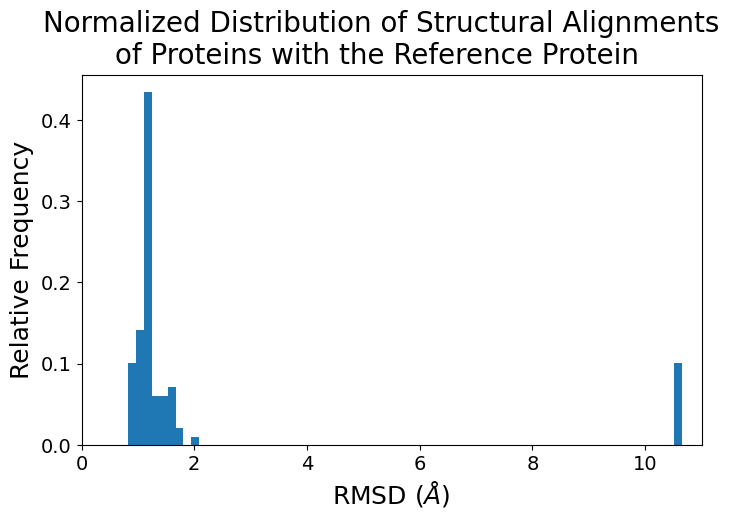

In [57]:
# Get rmsd for proteins and ref protein
axis_numb_size, leg_size, axis_size, title_size = 14, 16, 18, 20, 
from xaidar.data.molecModels import structAlign
raw_rmsd = structAlign( ref_prot, nonactive_prots[0]).calc_rmsd().rmsd
print(  raw_rmsd)

nonact_raw_rmsd_logs = []
for prot in nonactive_prots:
    nonact_raw_rmsd_logs.append( structAlign( ref_prot, prot).calc_rmsd().rmsd )

aligned_rmsd_logs = []
for prot in aligned_nonactive_prots:
    aligned_rmsd_logs.append( structAlign( ref_prot, prot).calc_rmsd().rmsd )

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots( 1, figsize = [8, 5], sharex=True, sharey=True )
for idx, (rmsd_logs, label, bin )in enumerate( zip([nonact_raw_rmsd_logs, aligned_rmsd_logs][:1],
                                              ["Not Aligned", "Aligned"][:1],
                                              [70, 10])):
    ax.hist( rmsd_logs, bins = bin, weights = np.ones_like( np.array(rmsd_logs)) / len(rmsd_logs)  )
    ax.set_xlabel( "RMSD ($\AA$)",  fontsize=axis_size,)
    ax.set_ylabel("Relative Frequency",  fontsize=axis_size, labelpad=5)
    ax.tick_params( labelsize=axis_numb_size)
    # ax.set_title("RMSE for {} Data".format(label))
plt.suptitle( "Normalized Distribution of Structural Alignments\nof Proteins with the Reference Protein ",  fontsize= title_size)
plt.xlim( 0, 11)
plt.subplots_adjust(
    hspace=0.1,  # Increase vertical space (e.g., to 50% of subplot height)
#     wspace=0.3,  # Increase horizontal space (e.g., to 30% of subplot width)
    top=0.85,     # Leave space at the top for a potential super title
#     bottom=0.1
)
plt.show()


In [58]:
# Filter Protein Sequences to only chains closest to the ligands mean CoM -> (lst_prots, prot_logs)
from xaidar.data.protocols import load_and_filter_Proteins

nonactive_prots, nonactive_logs = load_and_filter_Proteins( nonactivepdbs_dir, 
                                                                    mean_CoM )
fragscreen_prots, fragscreen_logs = load_and_filter_Proteins( fragscreen_dir, 
                                                                    mean_CoM )
piperid_prots, piperid_logs = load_and_filter_Proteins( piperid_dir, 
                                                                    mean_CoM )

print("\t\t       #Dirs  #AfterFilter")
print( "Nonactive Proteins:\t{}\t{}".format(len(list(nonactivepdbs_dir.iterdir())),
                                             len(nonactive_prots)))
print("FragScreen Proteins:\t{}\t{}".format(len(list(fragscreen_dir.iterdir())),
                                            len(fragscreen_prots)))
print("Piperid Proteins:  \t{}\t{}".format(len(list(piperid_dir.iterdir())),
                                           len(piperid_prots)))


# nonact_raw_rmsd_logs = []
# for prot in nonactive_prots:
#     raw_rmsd_logs.append( structAlign( ref_prot, prot).calc_rmsd().rmsd )
# print( nonact_raw_rmsd_logs[:10])

pip_raw_rmsd_logs = []
for prot in piperid_prots:
    pip_raw_rmsd_logs.append( structAlign( ref_prot, prot).calc_rmsd().rmsd )
print(pip_raw_rmsd_logs[:10])

frag_raw_rmsd_logs = []
for prot in fragscreen_prots:
    frag_raw_rmsd_logs.append( structAlign( ref_prot, prot).calc_rmsd().rmsd )
print(frag_raw_rmsd_logs[:10])
all_raw_rmsd_logs = nonact_raw_rmsd_logs + pip_raw_rmsd_logs + frag_raw_rmsd_logs


		       #Dirs  #AfterFilter
Nonactive Proteins:	99	99
FragScreen Proteins:	42	42
Piperid Proteins:  	454	454
[1.040465542904503, 1.1448402770199018, 0.8823318691438997, 1.2000666860001814, 0.9710196501703502, 0.8441009614643314, 1.2128618434199774, 1.2004304677529662, 0.6107283635304803, 0.9750522193751854]
[1.0769601502683865, 1.3673139448308194, 0.6680638985523912, 1.1817238122341174, 0.7707916865682874, 0.7978782800421581, 0.8896653803273061, 0.6056451408372054, 0.9177244318249143, 1.3717693695364737]


1.160799655037218


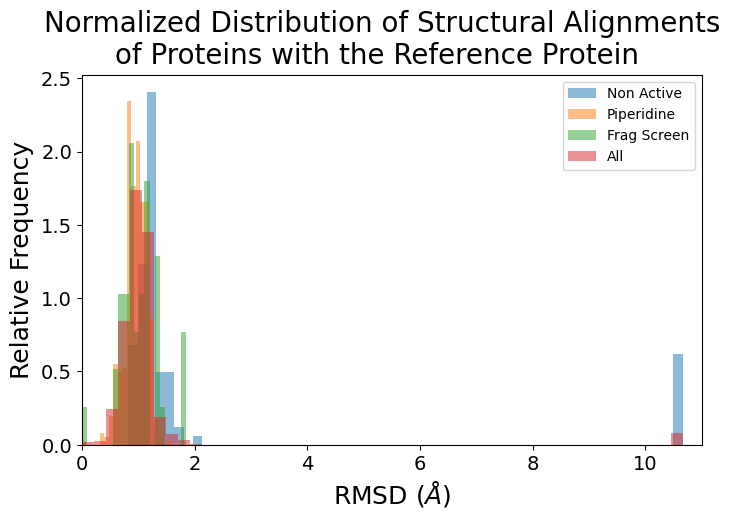

In [65]:
axis_numb_size, leg_size, axis_size, title_size = 14, 16, 18, 20, 
from xaidar.data.molecModels import structAlign
raw_rmsd = structAlign( ref_prot, nonactive_prots[0]).calc_rmsd().rmsd
print(  raw_rmsd)

raw_rmsd_logs = []
for prot in nonactive_prots:
    raw_rmsd_logs.append( structAlign( ref_prot, prot).calc_rmsd().rmsd )

aligned_rmsd_logs = []
for prot in aligned_nonactive_prots:
    aligned_rmsd_logs.append( structAlign( ref_prot, prot).calc_rmsd().rmsd )

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots( 1, figsize = [8, 5], sharex=True, sharey=True )
for rmsd_logs, label, bin in zip([nonact_raw_rmsd_logs, pip_raw_rmsd_logs,frag_raw_rmsd_logs, all_raw_rmsd_logs ],
                                              ["Non Active", "Piperidine", "Frag Screen", "All"],
                                              [60,20,20,50]):
    ax.hist( rmsd_logs, bins = bin, density = True, label= label, alpha = 0.5)
    ax.set_xlabel( "RMSD ($\AA$)",  fontsize=axis_size,)
    ax.set_ylabel("Relative Frequency",  fontsize=axis_size, labelpad=5)
    ax.tick_params( labelsize=axis_numb_size)
    # ax.set_title("RMSE for {} Data".format(label))
    ax.legend( )
plt.suptitle( "Normalized Distribution of Structural Alignments\nof Proteins with the Reference Protein ",  fontsize= title_size)
plt.xlim( 0, 11)
plt.subplots_adjust(
    hspace=0.1,  # Increase vertical space (e.g., to 50% of subplot height)
#     wspace=0.3,  # Increase horizontal space (e.g., to 30% of subplot width)
    top=0.85,     # Leave space at the top for a potential super title
#     bottom=0.1
)

plt.show()

1.160799655037218


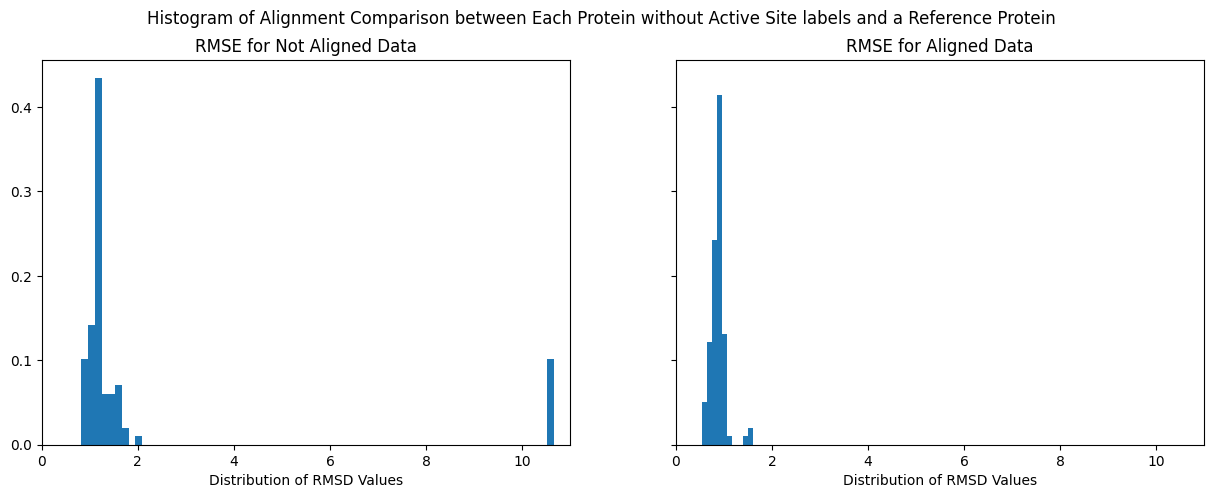

In [9]:
# Get rmsd for proteins and ref protein
from xaidar.data.molecModels import structAlign
raw_rmsd = structAlign( ref_prot, nonactive_prots[0]).calc_rmsd().rmsd
print(  raw_rmsd)

raw_rmsd_logs = []
for prot in nonactive_prots:
    raw_rmsd_logs.append( structAlign( ref_prot, prot).calc_rmsd().rmsd )

aligned_rmsd_logs = []
for prot in aligned_nonactive_prots:
    aligned_rmsd_logs.append( structAlign( ref_prot, prot).calc_rmsd().rmsd )

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots( 1, 2, figsize = [15, 5], sharex=True, sharey=True )
for idx, (rmsd_logs, label, bin )in enumerate( zip([raw_rmsd_logs, aligned_rmsd_logs],
                                              ["Not Aligned", "Aligned"],
                                              [70, 10])):
    ax[idx].hist( rmsd_logs, bins = bin, weights = np.ones_like( np.array(rmsd_logs)) / len(rmsd_logs)  )
    ax[idx].set_xlabel( "Distribution of RMSD Values")
    ax[idx].set_title("RMSE for {} Data".format(label))
plt.suptitle( "Histogram of Alignment Comparison between Each Protein without Active Site labels and a Reference Protein ")
plt.xlim( 0, 11)
plt.show()


In [10]:
print("Count Number of Proteins without Active Site label with ligands" \
"\nwith a distance or above X from active site:"\
"\n\nDistance: Count")
for distance in [ 5.0, 7.5, 10.0, 15.0,18.0, 19.0,19.2, 19.5, 19.7, 20.0, 25.0, 30.0, 35.0,  ]:
    datasets_away_from_active_site = [ nonactive_logs["dataset_name"][ idx ] 
                                    for idx, lig in enumerate(aligned_nonactive_ligs) 
                                    if ( np.linalg.norm( 
                                        ( get_res_CoM( flatten_pdb( lig, "residue")) -
                                        updated_mean_CoM))> distance )]
    if distance % 2.5 != 0:
        print("    {} : {} ".format(distance, len(datasets_away_from_active_site)))

    else:
        print("  {} : {} ".format(distance, len(datasets_away_from_active_site)))


Count Number of Proteins without Active Site label with ligands
with a distance or above X from active site:

Distance: Count
  5.0 : 74 
  7.5 : 74 
  10.0 : 66 
  15.0 : 62 
    18.0 : 56 
    19.0 : 55 
    19.2 : 51 
    19.5 : 48 
    19.7 : 45 
  20.0 : 39 
  25.0 : 11 
  30.0 : 0 
  35.0 : 0 


In [11]:

distance = 19
datasets_away_from_active_site = [ nonactive_logs["dataset_name"][ idx ] 
                                for idx, lig in enumerate(aligned_nonactive_ligs) 
                                if ( np.linalg.norm( 
                                    ( get_res_CoM( flatten_pdb( lig, "residue")) -
                                    updated_mean_CoM))> distance )]
print(distance, " : ", len(datasets_away_from_active_site))

nonactive_pair = [ (prot, lig, dataset_name) for prot, lig, dataset_name in zip( aligned_nonactive_prots, aligned_nonactive_ligs, nonactive_logs["dataset_name"] )
                                                                if dataset_name in datasets_away_from_active_site  ]
aligned_nonactive_prots = [ prot for prot, lig, dataset_name  in nonactive_pair ]
aligned_nonactive_ligs = [ lig for prot, lig, dataset_name  in nonactive_pair ] 

print( "Number of Proteins without Active Site Labels and away from Active Site: ", len(nonactive_pair) )

get_pdb_stats( nonactive_pair[0][0])
nonactive_pair_obj = []
nonactive_pair_names = []
for prot, lig, name in  nonactive_pair:
    new_obj = prot.clone()

    while len(new_obj[0]): del new_obj[0][ [chain.name for chain in new_obj[0]][0]] 
    
    new_obj[0].add_chain(gemmi.Chain("A"))
    new_obj[0]["A"].append_residues( flatten_pdb( prot, "residue") )
    new_obj[0].add_chain(gemmi.Chain("B"))
    new_obj[0]["B"].append_residues( flatten_pdb( lig, "residue") )

    # flatten_pdb( new_obj, "chain")[0].add_residue( flatten_pdb( lig, "residue")[0])
    nonactive_pair_obj.append( new_obj)
    nonactive_pair_names.append( name)

get_pdb_stats(  nonactive_pair_obj[0])


19  :  55
Number of Proteins without Active Site Labels and away from Active Site:  55

####################
Number of models: 1
Number of chains in 1st Model: 1

Chain ID: A
	Number of Residues: 140
	Unique List of Non-A.A.: set()
	Contains A.A.

####################
Number of models: 1
Number of chains in 1st Model: 2

Chain ID: A
	Number of Residues: 140
	Unique List of Non-A.A.: set()
	Contains A.A.
Chain ID: B
	Number of Residues: 1
	Unique List of Non-A.A.: {'LIG'}


- ## Get Piperidine Proteins

In [12]:
from xaidar.data.protocols import load_and_filter_Proteins
piperid_prots, piperid_logs = load_and_filter_Proteins( piperid_dir, updated_mean_CoM ,
                                dataset_subset = piperidine_dataset_codes    )
print( "Number of Piperid Proteins Loaded: ", len(piperid_prots) )
print("Range of Number of Chains within the Piperidine Proteins: ", set( [ len(prot[0]) for prot in piperid_prots ] ) )
print( piperid_logs["dataset_name"] == piperidine_dataset_codes)

Number of Piperid Proteins Loaded:  65
Range of Number of Chains within the Piperidine Proteins:  {1}
True


- ## Get Active Site Amino Acids

In [13]:
print( "Number of Active Site AA: ", len(activesite_aa_set))
print( sorted( activesite_aa_set, key= lambda res: res.seqid.num ) )

Number of Active Site AA:  33
[<gemmi.Residue 21(HIS) with 10 atoms>, <gemmi.Residue 22(LEU) with 8 atoms>, <gemmi.Residue 39(ASP) with 8 atoms>, <gemmi.Residue 82(ILE) with 8 atoms>, <gemmi.Residue 83(PHE) with 11 atoms>, <gemmi.Residue 84(VAL) with 7 atoms>, <gemmi.Residue 85(GLU) with 9 atoms>, <gemmi.Residue 86(ALA) with 5 atoms>, <gemmi.Residue 87(SER) with 6 atoms>, <gemmi.Residue 88(GLU) with 9 atoms>, <gemmi.Residue 89(TYR) with 12 atoms>, <gemmi.Residue 90(TYR) with 12 atoms>, <gemmi.Residue 93(ARG) with 11 atoms>, <gemmi.Residue 94(TYR) with 12 atoms>, <gemmi.Residue 95(GLN) with 9 atoms>, <gemmi.Residue 98(LEU) with 8 atoms>, <gemmi.Residue 100(LEU) with 8 atoms>, <gemmi.Residue 104(HIS) with 10 atoms>, <gemmi.Residue 105(SER) with 6 atoms>, <gemmi.Residue 106(GLU) with 9 atoms>, <gemmi.Residue 107(PRO) with 7 atoms>, <gemmi.Residue 108(GLY) with 4 atoms>, <gemmi.Residue 109(ASP) with 8 atoms>, <gemmi.Residue 110(CYS) with 6 atoms>, <gemmi.Residue 124(VAL) with 7 atoms>, <ge

In [14]:
from xaidar.data.molecModels import model_seqAlign
nonactive_prots_active_site_aa = []
for non_active_prot in aligned_nonactive_prots:
    matched_residues_dict = model_seqAlign(ref_prot , non_active_prot).map_matching_res().matched_res
    matched_residues = [ matched_residues_dict[ "Query"][idx] for idx in range(len( matched_residues_dict[ "Query"] ) )if 
                        matched_residues_dict[ "Ref"][idx] in activesite_aa_set ]
    nonactive_prots_active_site_aa.append( matched_residues )

pip_prots_active_site_aa = []
pip_prots_non_active_site_aa = []
for piperidine_prot in piperid_prots:    
    matched_residues_dict = model_seqAlign(ref_prot , piperidine_prot).map_matching_res().matched_res
    matched_residues = [ matched_residues_dict[ "Query"][idx] for idx in range(len( matched_residues_dict[ "Query"] ) )if 
                        matched_residues_dict[ "Ref"][idx] in activesite_aa_set ]
    pip_prots_active_site_aa.append( matched_residues )

    non_matched_residues = [ matched_residues_dict[ "Query"][idx] for idx in range( len(matched_residues_dict[ "Query"])   ) # len(matched_residues_dict[ "Query"]) 
                            if matched_residues_dict[ "Ref"][idx] not in activesite_aa_set ]
    pip_prots_non_active_site_aa.append( non_matched_residues )

    # print( len( matched_residues ) )
    # print( matched_residues )
# print( len( pip_prots_non_active_site_aa[0] ) )

- ## Get B-factors 

In [15]:
from xaidar.data.molecModels import get_res_bfactors

nonactive_bfactors = []
for res_list in nonactive_prots_active_site_aa:
    bfactors = get_res_bfactors( res_list , numpy_Array= True )
    nonactive_bfactors.append( bfactors )
nonactive_bfactors = np.array( nonactive_bfactors )

pip_bfactors = []
for res_list in pip_prots_active_site_aa:
    bfactors = get_res_bfactors( res_list , numpy_Array= True )
    pip_bfactors.append( bfactors )
pip_bfactors = np.array( pip_bfactors )

pip_nonactiv_bfactors = []
for res_list in pip_prots_non_active_site_aa:
    bfactors = get_res_bfactors( res_list , numpy_Array= True )
    pip_nonactiv_bfactors.append( bfactors )


print( set( [len(arr) for arr in pip_nonactiv_bfactors] ) )
pip_nonactiv_bfactors =  np.array([ arr[:-(len(arr) - 100 )] for arr in pip_nonactiv_bfactors ] )
print( set( [len(arr) for arr in pip_nonactiv_bfactors] ) )


{106, 107}
{100}


In [16]:
mean_nonactive_bfactors = np.mean( np.array( nonactive_bfactors ), axis = 0)

In [17]:
ground_bound_dif = pip_bfactors - mean_nonactive_bfactors
mean_ground_bound_dif = np.mean( ground_bound_dif, axis = 1)


In [18]:
from scipy.stats import pearsonr    
piperidine_ic50_values =np.array( [ float( ic50 ) for ic50 in piperidine_ic50_values ])

print( pearsonr( piperidine_ic50_values, mean_ground_bound_dif ) )

PearsonRResult(statistic=np.float64(-0.0032082018424715673), pvalue=np.float64(0.9797649976855064))


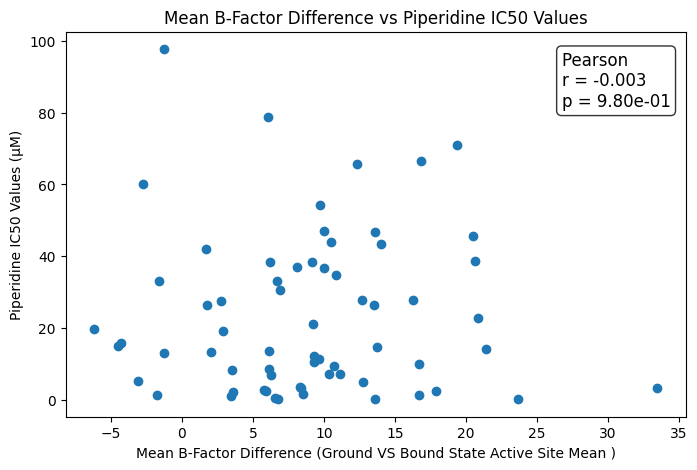

In [19]:
import matplotlib.pyplot as plt
x, y = mean_ground_bound_dif, piperidine_ic50_values
plt.figure( figsize = [8, 5])
plt.scatter( x, y)
plt.title( "Mean B-Factor Difference vs Piperidine IC50 Values")
plt.xlabel( "Mean B-Factor Difference (Ground VS Bound State Active Site Mean )")
plt.ylabel( "Piperidine IC50 Values (µM)")
r, p = pearsonr(x, y)
plt.gca().text(
    0.80, 0.95,
    f"Pearson \nr = {r:.3f}\np = {p:.2e}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
plt.show()


## Normalize the piperidine b-factors

In [20]:
print(pip_nonactiv_bfactors.shape)
print( np.mean( pip_nonactiv_bfactors, axis = 1).shape )

(65, 100)
(65,)


In [21]:
mean = np.mean( pip_nonactiv_bfactors, axis = 1)
# mean = np.mean( mean)
std = np.std( pip_nonactiv_bfactors, axis = 1)
norm_pip_bfactors = pip_bfactors.copy()
# norm_pip_bfactors =  norm_pip_bfactors - mean 
norm_pip_bfactors = (( norm_pip_bfactors.T - mean )/ std).T
print( norm_pip_bfactors.shape)

norm_dif = norm_pip_bfactors - mean_nonactive_bfactors
norm_mean_dif = np.mean( norm_dif, axis =1)
print( pearsonr( piperidine_ic50_values, norm_mean_dif ) )

(65, 33)
PearsonRResult(statistic=np.float64(0.16042705873279983), pvalue=np.float64(0.20174527722044838))


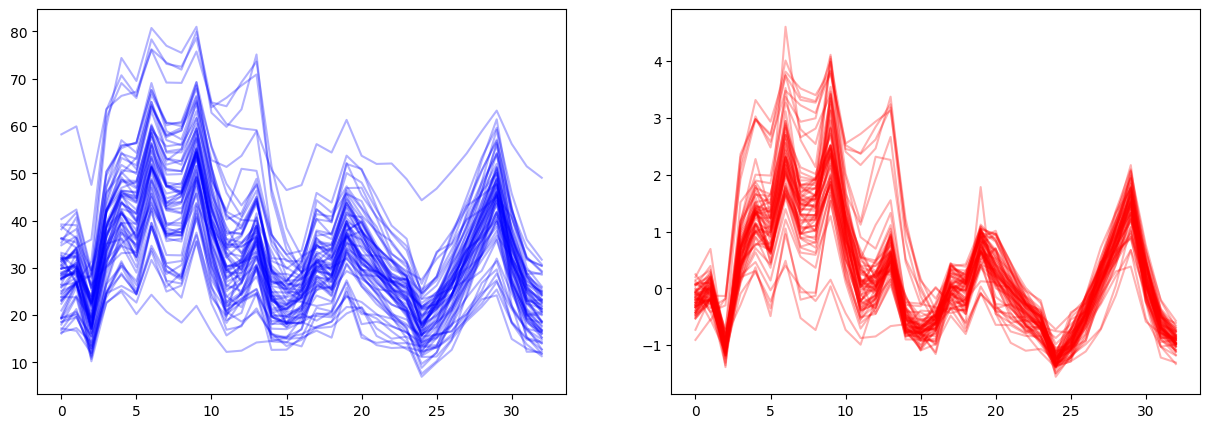

In [22]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots( 1, 2, figsize = [15, 5], sharex=True, sharey=False )
for factor in pip_bfactors:
    ax[0].plot(np.linspace( 0, len(pip_bfactors[0])-1, len(pip_bfactors[0]) ), factor, color = "blue", alpha = 0.3) 
for norm_factor in norm_pip_bfactors:
    ax[1].plot(np.linspace( 0, len(norm_pip_bfactors[0])-1, len(norm_pip_bfactors[0]) ), norm_factor, color = "red", alpha = 0.3)

plt.show()

In [23]:
print(norm_mean_dif.shape)

(65,)


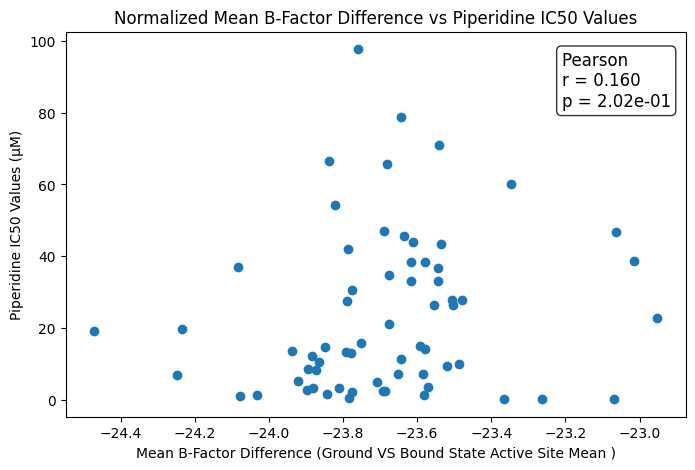

In [24]:
import matplotlib.pyplot as plt
x, y =  norm_mean_dif, piperidine_ic50_values
plt.figure( figsize = [8, 5])
plt.scatter( x, y)
plt.title( "Normalized Mean B-Factor Difference vs Piperidine IC50 Values")
plt.xlabel( "Mean B-Factor Difference (Ground VS Bound State Active Site Mean )")
plt.ylabel( "Piperidine IC50 Values (µM)")
r, p = pearsonr(x, y)
plt.gca().text(
    0.80, 0.95,
    f"Pearson \nr = {r:.3f}\np = {p:.2e}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
plt.show()

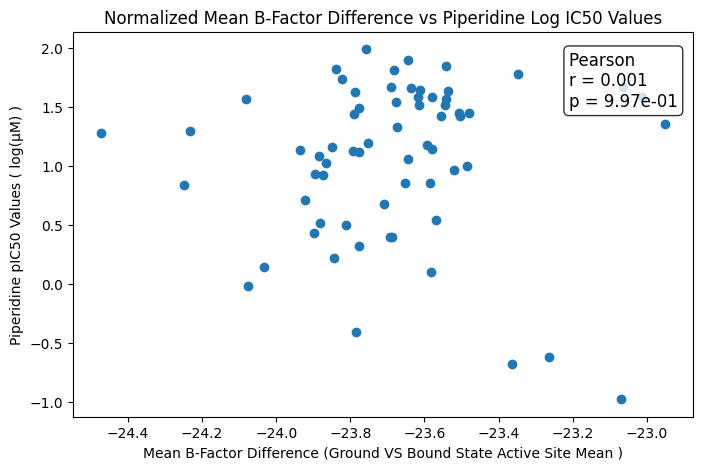

In [25]:
import matplotlib.pyplot as plt
x, y =  norm_mean_dif, piperidine_ic50_values
y = np.log10(y)
plt.figure( figsize = [8, 5])
plt.scatter( x, y)
plt.title( "Normalized Mean B-Factor Difference vs Piperidine Log IC50 Values")
plt.xlabel( "Mean B-Factor Difference (Ground VS Bound State Active Site Mean )")
plt.ylabel( "Piperidine pIC50 Values ( log(µM) )")
r, p = pearsonr(x, y)
plt.gca().text(
    0.80, 0.95,
    f"Pearson \nr = {r:.3f}\np = {p:.2e}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
plt.show()

In [26]:
print(piperidine_ic50_values.shape)
print(ground_bound_dif.shape)
print(ground_bound_dif[:,0].shape)

(65,)
(65, 33)
(65,)


In [27]:
# 6 // 6
6% 6


0

(33,)


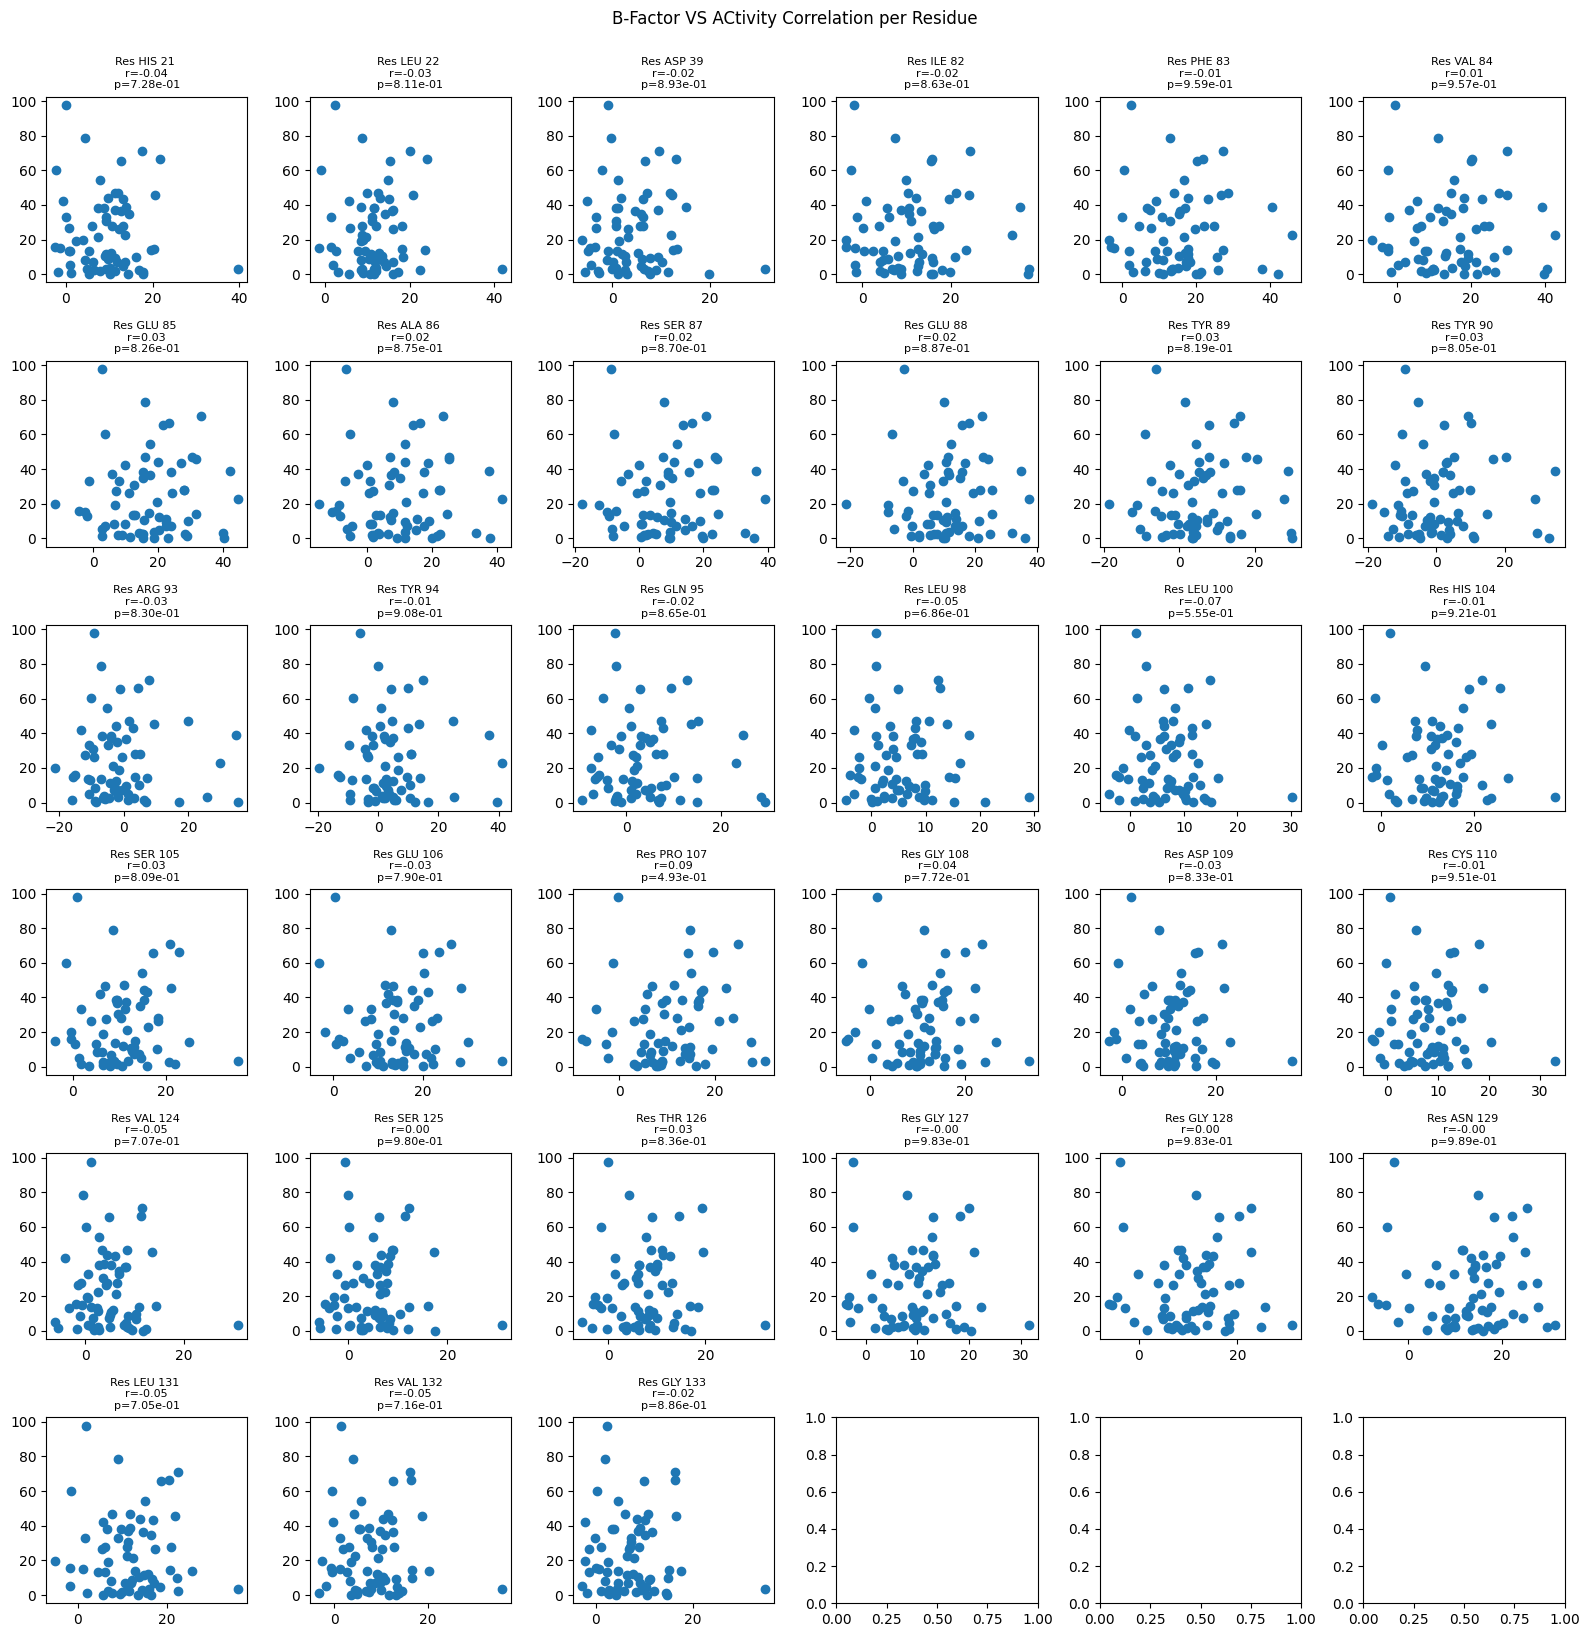

In [28]:
active_site_aa = sorted([ (res.name, res.seqid.num) for res in activesite_aa_set], key = lambda res: res[1] )

corr_per_res = np.array( [ pearsonr( ground_bound_dif[:,i], piperidine_ic50_values)[0] for i in range(ground_bound_dif.shape[1]) ] )
print( corr_per_res.shape )
fig, ax = plt.subplots( 6,6, figsize = [16, 16])
for i, res in zip( range(36), active_site_aa):
    if i >= ground_bound_dif.shape[1]:
        break
    x, y =  ground_bound_dif[:,i], piperidine_ic50_values
    ax[i // 6, i % 6].scatter( x, y)
    r, p = pearsonr(x, y)
    ax[i // 6, i % 6].set_title( "Res {} \nr={:.2f}\np={:.2e}".format( "{} {}".format(res[0], res[1]), r, p) , fontsize=8) 
# plt.suptitle( "Ground vs Bound B-Factor Difference per Residue vs Piperidine IC50 Values")
plt.tight_layout()
plt.suptitle( "B-Factor VS ACtivity Correlation per Residue", y=1.02)
plt.show()

In [29]:
# np.argmax( mean_ground_bound_dif)
print( mean_ground_bound_dif[np.argmax( mean_ground_bound_dif)] )
print( piperidine_dataset_codes[np.argmax( mean_ground_bound_dif)] )

33.47289256198348
A3940a


In [30]:
print( piperidine_dataset_codes)

['A3186a', 'A3207a', 'A3208a', 'A3225a', 'A3229a', 'A3510a', 'A3546a', 'A3548a', 'A3914a', 'A3920a', 'A3940a', 'A3942a', 'A3954a', 'A4292a', 'A4304a', 'A4319a', 'A4333a', 'A4336a', 'A4341a', 'A4342a', 'A4344a', 'A4346a', 'A4347a', 'A4373a', 'A4380a', 'A4381a', 'A4203a', 'A4209a', 'A4386a', 'A4388a', 'A4415a', 'A4464a', 'A4490a', 'A4528a', 'A4544a', 'A4546a', 'A4608a', 'A4650a', 'A4689a', 'A4695a', 'A4703a', 'A4724a', 'A4778a', 'A4812a', 'A4856a', 'A4908a', 'A4918a', 'A4980a', 'A5016a', 'A4914a', 'A4516a', 'A4670a', 'A4774a', 'A4872a', 'A5221a', 'A5249a', 'A5131a', 'A5666a', 'A5383a', 'A5402a', 'A5460a', 'A5466a', 'A5884a', 'A6738a', 'A6832a']
